# Week 06: Stats for Business: Is the Price Right?

You just joined the pricing team at a car-listing marketplace. Your manager has a few questions and one rule: **every claim needs a number, and every number needs a reason to trust it.**

**Data:** `cars.csv`: about 12,000 car trims (1990–2017) with specs and sticker price (MSRP). Source: [Car Features and MSRP (Kaggle)](https://www.kaggle.com/datasets/CooperUnion/cardataset). It's real data, so it's messy.

**What you'll practice** (all from this week's lecture):
- Cleaning before describing
- Mean vs median, skew, log transforms
- z-scores
- Bootstrap confidence intervals
- One- and two-sample tests, and picking the right one
- Confounding, and significant vs important

**How to answer:** Fill in the code cells, then write 1–3 sentences in each **Answer:** cell. Code without an interpretation is only half the job.

Plan for about 2–3 hours. 🚀 questions are optional stretch.

## Setup

In [1]:
# run this first if you dont have them installed in your env
!pip install pandas numpy matplotlib scipy


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Users\Rostyslav Kharevych\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_columns", None)
rng = np.random.default_rng(42)  # use rng for all random sampling so your results are reproducible

df = pd.read_csv("data/cars.csv")
print(df.shape)
df.head()

(11914, 15)


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,18,3916,34500


---
## Part 1: Can you trust this data?

### Q1. Find the problems before you average anything

This dataset has **at least five** real problems. Find them, fix or flag each one, and build a cleaned DataFrame called `clean`. You'll use `clean` for the rest of the notebook.

Use your Week 02 cleaning checklist. Some nudges, in no particular order:
- Count things twice.
- The most common value in a column can be more suspicious than the largest one.
- Would you print every max value in a sales brochure?
- Missing values usually have a reason. *Who* is missing?
- Is every number in a column measured in the same unit?
- Does every column vary at the level you'd expect?
- Not everything weird is wrong.

For each problem, decide: **drop it, set it to NaN, flag it, or leave it**. Dropping whole rows is the last resort, because a row with a bad price may still have a good MPG.

In [39]:
# Explore here. Add as many cells as you need.
# Useful: .duplicated(), .value_counts(), .describe(), .isna().sum(), .nlargest(), .groupby(...).nunique()
df.info()

print(df.columns.to_list())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  object 
 1   Model              11914 non-null  object 
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  object 
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  object 
 7   Driven_Wheels      11914 non-null  object 
 8   Number of Doors    11908 non-null  float64
 9   Vehicle Size       11914 non-null  object 
 10  Vehicle Style      11914 non-null  object 
 11  highway MPG        11914 non-null  int64  
 12  city mpg           11914 non-null  int64  
 13  Popularity         11914 non-null  int64  
 14  MSRP               11914 non-null  int64  
dtypes: float64(3), int64(5), object(7)
memory usage: 1.4+ MB
['Make', 'Mod

In [40]:
# Count duplicates
duplicates = df.duplicated().sum()
print(f"Total duplicate rows: {duplicates}")

# Display duplicates
duplicate_rows = df[df.duplicated(keep=False)]
print(duplicate_rows.head(5))

Total duplicate rows: 720
    Make     Model  Year             Engine Fuel Type  Engine HP  \
11   BMW  1 Series  2013  premium unleaded (required)      230.0   
14   BMW  1 Series  2013  premium unleaded (required)      230.0   
17  Audi       100  1992             regular unleaded      172.0   
18  Audi       100  1992             regular unleaded      172.0   
20  Audi       100  1992             regular unleaded      172.0   

    Engine Cylinders Transmission Type      Driven_Wheels  Number of Doors  \
11               6.0            MANUAL   rear wheel drive              2.0   
14               6.0            MANUAL   rear wheel drive              2.0   
17               6.0            MANUAL  front wheel drive              4.0   
18               6.0            MANUAL  front wheel drive              4.0   
20               6.0            MANUAL  front wheel drive              4.0   

   Vehicle Size Vehicle Style  highway MPG  city mpg  Popularity   MSRP  
11      Compact       

In [41]:
# Calculate Nulls and the percentage of the data they represent
missing_summary = pd.DataFrame(
    {"Missing count": df.isnull().sum(), "Missing %": df.isnull().mean()*100}
)
print(missing_summary[missing_summary["Missing count"] > 0])

                  Missing count  Missing %
Engine Fuel Type              3   0.025180
Engine HP                    69   0.579151
Engine Cylinders             30   0.251805
Number of Doors               6   0.050361


In [42]:
# Inspect if Engine Fuel Type can explain Nulls in Engine Cylinders
print(df[df["Engine Cylinders"].isnull()][["Make", "Model", "Engine Fuel Type"]])

            Make    Model             Engine Fuel Type
1983   Chevrolet  Bolt EV                     electric
1984   Chevrolet  Bolt EV                     electric
3716  Volkswagen   e-Golf                     electric
3717  Volkswagen   e-Golf                     electric
3718  Volkswagen   e-Golf                     electric
3719  Volkswagen   e-Golf                     electric
5778  Mitsubishi   i-MiEV                     electric
5779  Mitsubishi   i-MiEV                     electric
5780  Mitsubishi   i-MiEV                     electric
8373      Toyota  RAV4 EV                     electric
8695       Mazda     RX-7             regular unleaded
8696       Mazda     RX-7             regular unleaded
8697       Mazda     RX-7             regular unleaded
8698       Mazda     RX-8  premium unleaded (required)
8699       Mazda     RX-8  premium unleaded (required)
8700       Mazda     RX-8  premium unleaded (required)
8701       Mazda     RX-8  premium unleaded (required)
8702      

In [43]:
categorical_cols = df.select_dtypes(include=["object"]).columns

for col in categorical_cols:
    unique_vals = df[col].unique()
    # Check for known placeholder markers
    suspicious = [
        val for val in unique_vals if str(val).lower() in ["unknown", "n/a", "?", "none", ""]
    ]
    if suspicious:
        print(f"Column '{col}' contains placeholder values: {suspicious}")
        print(df[col].value_counts().loc[suspicious])

Column 'Transmission Type' contains placeholder values: ['UNKNOWN']
Transmission Type
UNKNOWN    19
Name: count, dtype: int64


In [44]:
print(df.describe())

               Year    Engine HP  Engine Cylinders  Number of Doors  \
count  11914.000000  11845.00000      11884.000000     11908.000000   
mean    2010.384338    249.38607          5.628829         3.436093   
std        7.579740    109.19187          1.780559         0.881315   
min     1990.000000     55.00000          0.000000         2.000000   
25%     2007.000000    170.00000          4.000000         2.000000   
50%     2015.000000    227.00000          6.000000         4.000000   
75%     2016.000000    300.00000          6.000000         4.000000   
max     2017.000000   1001.00000         16.000000         4.000000   

        highway MPG      city mpg    Popularity          MSRP  
count  11914.000000  11914.000000  11914.000000  1.191400e+04  
mean      26.637485     19.733255   1554.911197  4.059474e+04  
std        8.863001      8.987798   1441.855347  6.010910e+04  
min       12.000000      7.000000      2.000000  2.000000e+03  
25%       22.000000     16.000000    549

In [45]:
# Flag any non-electric car exceeding 70 MPG
unrealistic_gas_mpg = df[
    (df["Engine Fuel Type"] != "electric") & (df["highway MPG"] > 70)
]
print(
    unrealistic_gas_mpg[["Make", "Model", "Year", "highway MPG", "city mpg"]]
)

      Make Model  Year  highway MPG  city mpg
1119  Audi    A6  2017          354        24


In [46]:
# Look at the 10 lowest and 10 highest prices
print(df.nsmallest(10, "MSRP")[["Make", "Model", "Year", "MSRP"]])
print(df.nlargest(10, "MSRP")[["Make", "Model", "Year", "MSRP"]])

    Make Model  Year  MSRP
17  Audi   100  1992  2000
18  Audi   100  1992  2000
19  Audi   100  1992  2000
20  Audi   100  1992  2000
21  Audi   100  1992  2000
22  Audi   100  1993  2000
23  Audi   100  1993  2000
24  Audi   100  1993  2000
25  Audi   100  1993  2000
26  Audi   100  1993  2000
              Make        Model  Year     MSRP
11362      Bugatti  Veyron 16.4  2008  2065902
11364      Bugatti  Veyron 16.4  2009  1705769
8486   Lamborghini     Reventon  2008  1500000
11363      Bugatti  Veyron 16.4  2008  1500000
6351       Maybach    Landaulet  2012  1382750
6350       Maybach    Landaulet  2011  1380000
4024       Ferrari         Enzo  2003   643330
1622   Lamborghini    Aventador  2014   548800
1626   Lamborghini    Aventador  2015   548800
1629   Lamborghini    Aventador  2016   535500


In [47]:
# Check how many cars are stuck at the minimum MSRP
print(df["MSRP"].value_counts().head(5))

MSRP
2000     1036
29995      19
25995      19
27995      16
20995      16
Name: count, dtype: int64


In [48]:
# 1. Standardize column headers
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# 2. Correct data entry typo for Audi A6 highway MPG
df.loc[
    (df["make"] == "Audi") & (df["model"] == "A6") & (df["highway_mpg"] == 354),
    "highway_mpg",
] = 34

# 3. Standardize hidden placeholder strings to proper NaN
df["transmission_type"] = df["transmission_type"].replace("UNKNOWN", pd.NA)

# 4. Drop duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

# 5. Fix Engine Cylinders based on vehicle mechanics
# Set electric vehicles to 0 cylinders
df.loc[df["engine_fuel_type"] == "electric", "engine_cylinders"] = df.loc[
    df["engine_fuel_type"] == "electric", "engine_cylinders"].fillna(0)

# Set rotary engines (Mazda RX-7, RX-8) to 0 cylinders (pistonless)
rotary_mask = df["model"].str.contains("RX-7|RX-8", na=False)
df.loc[rotary_mask, "engine_cylinders"] = df.loc[
    rotary_mask, "engine_cylinders"
].fillna(0)

# 6. Impute remaining missing values
# Door counts: 2 doors for Ferrari FF (coupe), 4 doors for Tesla Model S (sedan)
df.loc[
    (df["model"] == "FF") & (df["number_of_doors"].isna()), "number_of_doors"
] = 2.0
df.loc[
    (df["model"] == "Model S") & (df["number_of_doors"].isna()),
    "number_of_doors",
] = 4.0

# Engine HP: impute non-electric cars by median of matching Make & Model
df["engine_hp"] = df.groupby(["make", "model"])["engine_hp"].transform(
    lambda group: group.fillna(group.median())
)

# Engine Fuel Type: fill the 3 missing records with the most common fuel type for that model
df["engine_fuel_type"] = df.groupby("model")["engine_fuel_type"].transform(
    lambda group: group.fillna(
        group.mode()[0] if not group.mode().empty else "regular unleaded"
    )
)

# 7. Cast discrete numerical features to nullable integers
df["engine_cylinders"] = df["engine_cylinders"].astype("Int64")
df["number_of_doors"] = df["number_of_doors"].astype("Int64")

# 8. Filter or flag artificial MSRP scrap price floor
# Flag floor rows so downstream models can exclude or isolate them
df["is_floor_msrp"] = df["msrp"] <= 2000

**Cleaning log:** fill in one row per problem.

| # | Problem | How I found it | Rows affected | What I did | Why |
|---|---|---|---|---|---|
| 1 | | | | | |
| 2 | | | | | |
| 3 | | | | | |
| 4 | | | | | |
| 5 | | | | | |

In [49]:
# Build your cleaned DataFrame. Start from a copy so df stays untouched.
clean = df.copy()
clean.columns = clean.columns.str.strip().str.lower().str.replace(" ", "_")  # freebie: snake_case names

In [50]:
# Checkpoint: run this before moving on.
print(clean.shape)
print(clean.isna().sum()[clean.isna().sum() > 0])
# Fewer than ~10,000 rows? You probably dropped too much. Go back and use NaN or a flag instead.

(11194, 16)
engine_hp            38
transmission_type    12
dtype: int64


In [54]:
print(clean.duplicated().sum())
print(clean.columns.to_list())

0
['make', 'model', 'year', 'engine_fuel_type', 'engine_hp', 'engine_cylinders', 'transmission_type', 'driven_wheels', 'number_of_doors', 'vehicle_size', 'vehicle_style', 'highway_mpg', 'city_mpg', 'popularity', 'msrp', 'is_floor_msrp']


---
## Part 2: Describe

### Q2. What does a "typical" car cost?

Your manager wants one number for "typical price" on the homepage.

a) Compute the mean and median MSRP. Which is bigger, and why?

b) Plot a histogram of MSRP, then a histogram of `np.log10(msrp)`. Describe each shape in a few words.

c) What percent of cars cost more than the mean?

d) Which number belongs on the homepage? Why?

Cleaned Data


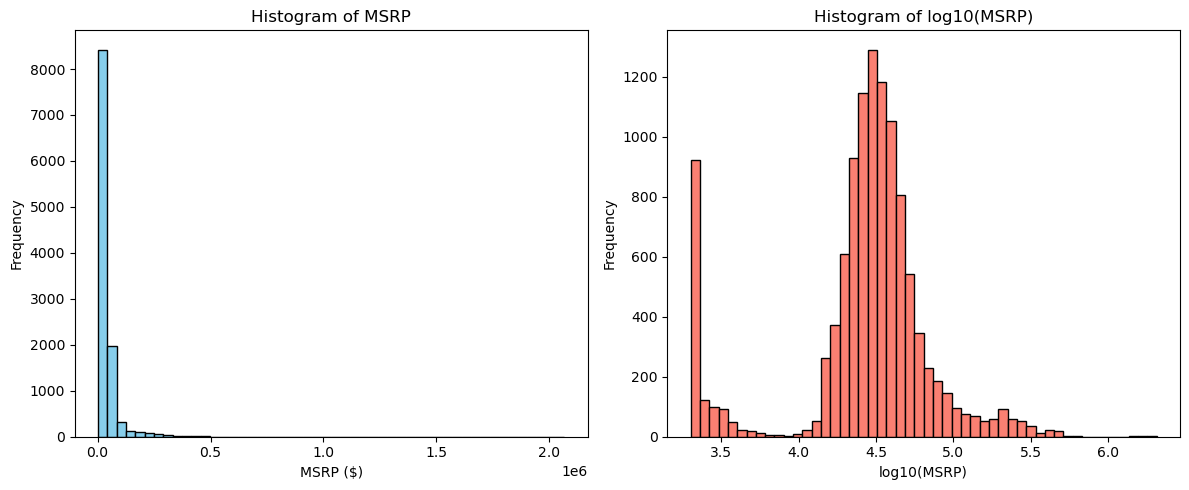

Mean: 41933.29, Median: 30675.00, Pct > Mean: 26.68%


In [ ]:
# a) mean and median
print("Cleaned Data")
mean = clean['msrp'].mean()
median = clean['msrp'].median()

# b) two histograms side by side (plt.subplots(1, 2))
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram of MSRP
axes[0].hist(clean["msrp"], bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('Histogram of MSRP')
axes[0].set_xlabel('MSRP ($)')
axes[0].set_ylabel('Frequency')

# Histogram of np.log10(MSRP)
axes[1].hist(np.log10(clean['msrp']), bins=50, color='salmon', edgecolor='black')
axes[1].set_title('Histogram of log10(MSRP)')
axes[1].set_xlabel('log10(MSRP)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# c) share of cars above the mean
pct_above_mean = (clean['msrp'] > mean).mean() * 100

print(f"Mean: {mean:.2f}, Median: {median:.2f}, Pct > Mean: {pct_above_mean:.2f}%")

**Answer:**
a) Mean vs. Median MSRP
* Cleaned Dataset:
    * Mean: $41,933.29
    * Median: $30,675.00

Which is bigger and why:
- The mean is significantly larger than the median (by over $11,000). The mean is catches extreme values, so it gets overestimated by exotics and hypercars in the right tail (such as the Bugatti Veyron at $2,065,902 and Lamborghini Reventon at $1,500,000). The median represents the exact middle price point and remains resistant to high-end outliers.

b) Histrogram interpretation
- MSRP is Heavily right-skewed with a long tail stretching out past $2,000,000. Nearly all mass is located in the first bin under $100,000.
- np.log10(msrp) is Bimodal with an approximately normal main body. It features an artificial left spike at $\approx 3.3$ representing the $2,000 synthetic price floor, since $10^{3.3} \approx 2000$, followed by an approximately symmetric, bell-shaped distribution centered around $4.5$ ($\approx \$31,600$).

c) Percent of Cars Costing More Than the Mean
- 26.68% (only 2,987 out of 11,194 cars cost more than the mean).
- Roughly 73% of cars cost less than the mean, proving the mean is not representative of a typical car and we might consider using median as our main metric instead.

d) Which Number Belongs on the Homepage?
- The Median (~$30,000 – $30,675) belongs on the homepage.
- Why: For heavily skewed distributions, the median represents the true middle consumer experience. Half of all available cars cost less than ~$30,675, and half cost more. Putting the mean ($41,933) on the homepage misleads buyers into thinking typical inventory is over $11,000 more expensive than it actually is, distorted entirely by a small handful of multimillion-dollar exotics.

### Q3. Fuel-efficient *for its size*?

Two 2017 cars:
- **Honda Civic** (Compact): 42 highway MPG
- **Volvo S90** (Large): 34 highway MPG

The Civic wins on raw MPG, but large cars are heavier. Which one is more impressive *for its class*?

a) For 2017 cars (only the MPG values you trust after Q1), compute the mean and standard deviation of highway MPG for each `vehicle_size`.

b) Compute each car's z-score within its own size class.

c) Which is more fuel-efficient for its class? How unusual is each one?

In [ ]:
# a) mean and std of highway_mpg by vehicle_size, 2017 only

# b) z = (value - class mean) / class std

**Answer:**

---
## Part 3: Uncertainty

### Q4. How sure are we about the median price?

The 2017 cars are one snapshot of the market. With a slightly different set of cars, the median would move. A bootstrap shows how much.

a) Compute the median MSRP of 2017 cars.

b) Bootstrap it: resample the 2017 prices **with replacement** 5,000 times and take the median each time. Plot the 5,000 medians and report the 95% interval (2.5th and 97.5th percentiles).

c) Repeat for 2017 cars from **one make** with fewer than 50 cars that year (your choice). Is the interval wider or narrower? Why?

d) Explain the interval from (b) in one sentence a manager would understand.

In [ ]:
def bootstrap_median(values, n_boot=5000):
    """Return an array of n_boot bootstrap medians."""
    # hint: rng.choice(values, size=len(values), replace=True)
    pass

# a, b)

# c)

**Answer:**

---
## Part 4: Testing

### Q5. Can marketing say "our 2017 compacts average over 30 MPG"?

a) Write H₀ and Hₐ. One-sided or two-sided? Why?

b) How many cars are in the sample, and what does the distribution look like? Is a t-test reasonable here?

c) Run a one-sample t-test at α = 0.05 (`stats.ttest_1samp(..., alternative="greater")`). State the conclusion in plain English.

d) **Independence check.** Tests assume each row is an independent observation. Count how many rows each `make` + `model` has in this sample. Then average to one row per model and rerun the test. What changed, and which version do you trust more?

In [ ]:
# b) sample: 2017 compact cars (MPG you trust); n, mean, histogram

# c) one-sample t-test vs 30

# d) rows per make+model, then one row per model and retest

**Answer:**

### Q6. Do manual cars cost less? (the big one)

A sales rep says: *"Manual cars are way cheaper. We should push manuals to budget shoppers."*

Compare `AUTOMATIC` vs `MANUAL` only.

a) Compare the median MSRP of the two groups.

b) Before believing it, compare the `year` of manual vs automatic cars. What do you notice?

c) Redo (a) using only 2015–2017 cars, then within each `vehicle_size`. For 2015–17 compacts, use the Mann–Whitney U test (`stats.mannwhitneyu(auto, manual)`) to compare prices.

- What do the p-value and medians suggest?

d) Write one sentence back to the sales rep.

In [ ]:
# a) compare median MSRP by transmission type

# b) compare year by transmission type

# c) compare 2015-2017 medians overall and within each vehicle_size
# For 2015-17 compacts, test automatic vs manual prices with:
# stats.mannwhitneyu(auto, manual)

**Answer:**

### Q7. Significant ≠ important

Among cars whose MPG you trust, 4-door cars get better highway MPG than 2-door cars.

a) Run a Welch t-test. Report the difference in means and the p-value.

b) Translate the difference into dollars. Assume 12,000 miles/year and \$3.50/gallon. How much does the average 4-door driver save per year?

c) Now pretend you only had **30 cars per group.** Draw 30 random 4-door and 30 random 2-door cars, run the same test, and repeat 1,000 times. What fraction of those tests come out significant (p < 0.05)?

d) Would you put "4-door cars are significantly more fuel-efficient" in an ad? What would you say instead?

In [ ]:
# a) Welch t-test, 4-door vs 2-door

# b) yearly gas cost = miles * price_per_gallon / mpg

# c) simulation
n_sims, hits = 1000, 0
for _ in range(n_sims):
    # sample 30 from each group with rng.choice(..., 30, replace=False), run the test, count p < 0.05
    pass

**Answer:**

---
## Part 5: Communicate

### Q8. Your memo to the pricing manager

Write 4–6 sentences. Include:
- Your answer to "do manual cars cost less?", with at least one number
- One other finding from this notebook that matters for pricing
- One limitation of this data a manager should know about

No unexplained jargon: if you say "significant," say what it means.

**Memo:**

---
## 🚀 Stretch (optional)

### 🚀 S1. Horsepower and price

a) Compute the correlation between `engine_hp` and `msrp` three ways: Pearson, Pearson with `np.log10(msrp)`, and Spearman. Why do they differ?

b) Scatter plot HP vs MSRP with a log y-axis (`plt.yscale("log")`).

c) Does adding horsepower *cause* a higher price? Name one lurking variable.

In [ ]:
# S1

### 🚀 S2. Is transmission tied to vehicle size?

For 2015–2017 cars (automatic and manual only), build a crosstab of `vehicle_size` × `transmission_type` and run a chi-square test (`stats.chi2_contingency`). How does this connect to Q6?

In [ ]:
# S2